最近在读 *TorchOptics: An open-source Python library for differentiable Fourier optics simulations* (arXiv:2411.18591)，本文复现其中 Figure 4 的 端到端 differentiable inverse-design 例子。

## 问题

给定一束输入 Gaussian beam，**直接优化**三块 phase-only SLM 的相位分布，使输出光场在目标平面匹配 *四束* Gaussian beam 的模式。整套系统里没有任何手工设计的相位或 Fourier 变换 mask —— 相位就是待优化参数。

## 系统布局

$$
\mathrm{Gaussian}_{\rm in}
\;\xrightarrow{M_1}\; P\;
\xrightarrow{M_2}\; P\;
\xrightarrow{M_3}\; P\;
\to \;\mathrm{four\;Gaussians}_{\rm out}
$$

三块 phase modulator $M_i = e^{i\phi_i(x,y)}$ 沿 $z$ 轴等距分布：

| 位置 | 距离 |
| --- | --- |
| $M_1$ | $z = 0.00\,\rm m$ |
| $M_2$ | $z = 0.20\,\rm m$ |
| $M_3$ | $z = 0.40\,\rm m$ |
| 目标面 | $z = 0.60\,\rm m$ |

每两块 SLM 之间的自由空间传播距离均为 $0.2\,\rm m$。

## 数值参数

| 参数 | 值 |
| --- | --- |
| 网格 | $250 \times 250$ |
| Pixel pitch | $10\,\mu\rm m$ |
| 波长 $\lambda$ | $700\,\rm nm$ |
| Gaussian waist $w_0$ | $150\,\mu\rm m$ |
| 目标束偏移 | $\pm 0.5\,\rm mm$（$\pm x$、$\pm y$ 四个象限） |
| 优化器 | Adam, $\mathrm{lr}=0.1$ |

## 优化变量

三块相位板的 phase profile $\phi_1,\phi_2,\phi_3$ 均从零相位开始 —— 初始系统等价于输入 Gaussian 自由传播 $0.6\,\rm m$。优化目标是最小化

$$
L = 1 - \eta, \qquad
\eta = \frac{\left|\int U_{\rm target}^*\, U_{\rm out}\, dA\right|^2}
            {\int |U_{\rm out}|^2 dA \cdot \int |U_{\rm target}|^2 dA},
$$

即 mode-overlap efficiency $\eta$。


In [39]:
import torch
import matplotlib.pyplot as plt

# --- Numerical grid ---
wavelength = 700e-9  # 700 nm
Nx = 250
Ny = 250
dx = dy = 10e-6  # 10 um pixel pitch

# --- Source / target ---
w0 = 150e-6  # input Gaussian waist (= target waist)
target_offset = 0.5e-3  # distance of target beam centers from optical axis

# --- Optimizer ---
learning_rate = 0.1
n_iters = 100  # paper trains for 400 iterations

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
real_dtype = torch.float64
complex_dtype = torch.complex128

x = (torch.arange(Nx, dtype=real_dtype) - Nx // 2) * dx

y = (torch.arange(Ny, dtype=real_dtype) - Ny // 2) * dy

Y, X = torch.meshgrid(
    y,
    x,
    indexing="ij",
)

## 准备输入场与目标场

In [41]:
def gaussian_beam(X, Y, w0, x0=0.0, y0=0.0):
    """A real-valued Gaussian beam profile on the centered (X, Y) grid."""
    R2 = (X - x0) ** 2 + (Y - y0) ** 2
    return torch.exp(-R2 / w0**2)


def normalize_power(U, dx, dy=None):
    """Normalize so that the integrated intensity (∫|U|² dA) equals 1."""
    if dy is None:
        dy = dx
    power = torch.sum(torch.abs(U) ** 2) * dx * dy
    return U / torch.sqrt(power)


# Input: a single on-axis Gaussian beam.
U_in = normalize_power(gaussian_beam(X, Y, w0), dx)


def four_gaussian_target(X, Y, w0, offset):
    """Four Gaussian beams at the corners of a square of side 2*offset."""
    centers = [
        (-offset, -offset),
        (-offset, +offset),
        (+offset, -offset),
        (+offset, +offset),
    ]
    return sum(gaussian_beam(X, Y, w0, cx, cy) for cx, cy in centers)


U_target = normalize_power(four_gaussian_target(X, Y, w0, target_offset), dx)

## 构建可微的传播算子

In [42]:
def phase_modulate(U, phi):
    """Apply a phase-only mask phi to a complex field U."""
    return U * torch.exp(1j * phi)


def make_transfer_function(
    Nx, Ny, dx, dy, wavelength, z, real_dtype, complex_dtype, device
):
    fx = torch.fft.fftshift(
        torch.fft.fftfreq(Nx, d=dx, dtype=real_dtype, device=device)
    )
    fy = torch.fft.fftshift(
        torch.fft.fftfreq(Ny, d=dy, dtype=real_dtype, device=device)
    )
    FY, FX = torch.meshgrid(fy, fx, indexing="ij")

    k = 2 * torch.pi / wavelength
    KX = 2 * torch.pi * FX
    KY = 2 * torch.pi * FY
    kz2 = k**2 - KX**2 - KY**2
    KZ = torch.sqrt(kz2.to(complex_dtype))
    return torch.exp(1j * z * KZ)


def fft2c(U):
    return torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(U)))


def ifft2c(A):
    return torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(A)))


def propagate(
    U,
    H,
):
    spectrum = fft2c(U)

    propagated_spectrum = spectrum * H

    return ifft2c(propagated_spectrum)

## 把物理系统封装为 `nn.Module`

In [43]:
class ThreePlanePhaseSystem(torch.nn.Module):
    def __init__(
        self,
        Ny,
        Nx,
        H1,
        H2,
        H3,
        dtype=torch.float64,
    ):
        super().__init__()

        self.phi1 = torch.nn.Parameter(torch.zeros(Ny, Nx, dtype=dtype))

        self.phi2 = torch.nn.Parameter(torch.zeros(Ny, Nx, dtype=dtype))

        self.phi3 = torch.nn.Parameter(torch.zeros(Ny, Nx, dtype=dtype))

        self.register_buffer("H1", H1)
        self.register_buffer("H2", H2)
        self.register_buffer("H3", H3)

    def forward(self, U):
        U = phase_modulate(U, self.phi1)
        U = propagate(U, self.H1)

        U = phase_modulate(U, self.phi2)
        U = propagate(U, self.H2)

        U = phase_modulate(U, self.phi3)
        U = propagate(U, self.H3)

        return U

In [44]:
H1 = make_transfer_function(
    Nx,
    Ny,
    dx,
    dy,
    wavelength,
    z=0.2,
    device=device,
    real_dtype=real_dtype,
    complex_dtype=complex_dtype,
)

H2 = make_transfer_function(
    Nx,
    Ny,
    dx,
    dy,
    wavelength,
    z=0.2,
    device=device,
    real_dtype=real_dtype,
    complex_dtype=complex_dtype,
)

H3 = make_transfer_function(
    Nx,
    Ny,
    dx,
    dy,
    wavelength,
    z=0.2,
    device=device,
    real_dtype=real_dtype,
    complex_dtype=complex_dtype,
)

In [45]:
model = ThreePlanePhaseSystem(
    Ny,
    Nx,
    H1,
    H2,
    H3,
    dtype=real_dtype,
).to(device)

U_out = model(U_in)

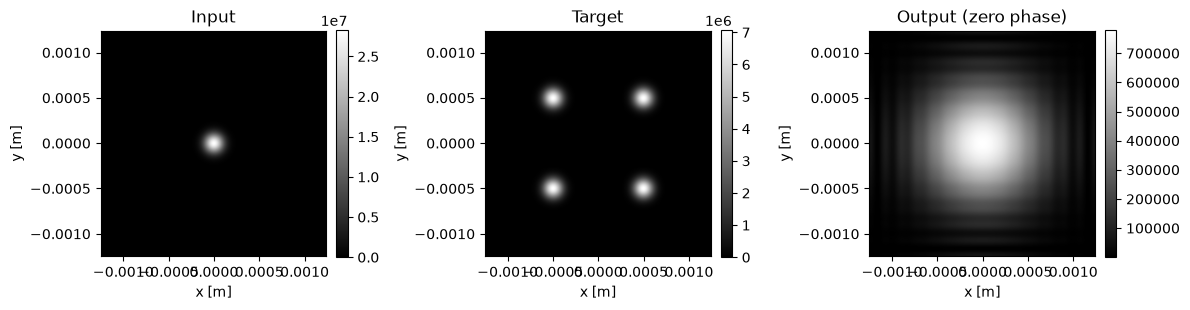

In [46]:
extent = [
    x.min().item(),
    x.max().item(),
    y.min().item(),
    y.max().item(),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, U, title in zip(
    axes,
    [U_in, U_target, U_out],
    ["Input", "Target", "Output (zero phase)"],
):
    I = (torch.abs(U) ** 2).detach().cpu().numpy()

    im = ax.imshow(
        I,
        extent=extent,
        origin="lower",
        cmap="gray",
    )

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

plt.tight_layout()
plt.show()

## 定义损失并执行优化

In [47]:
def mode_overlap(U_out, U_target, dx, dy):
    inner = torch.sum(torch.conj(U_target) * U_out) * dx * dy
    power_out = torch.sum(torch.abs(U_out) ** 2) * dx * dy
    power_target = torch.sum(torch.abs(U_target) ** 2) * dx * dy
    eta = torch.abs(inner) ** 2 / (power_out * power_target)
    return eta.real

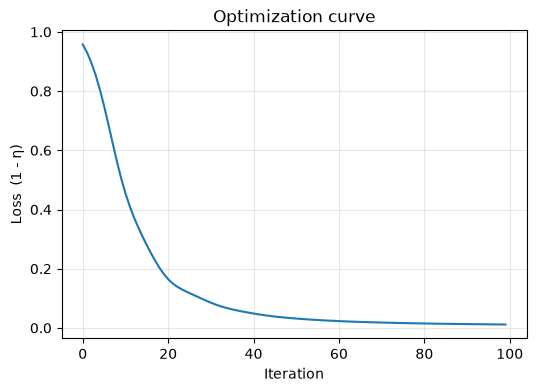

In [ ]:
history = []

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
)

for iteration in range(n_iters):

    optimizer.zero_grad()

    U_out = model(U_in)

    eta = mode_overlap(
        U_out,
        U_target,
        dx,
        dy,
    )

    loss = 1 - eta
    history.append(float(loss))

    loss.backward()

    optimizer.step()

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Loss  (1 - η)")
plt.title("Optimization curve")
plt.grid(alpha=0.3)
plt.show()